This cell imports the core libraries for data processing and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

This cell loads the dataset and adjusts display settings for easier inspection.

In [2]:
pd.set_option('display.max_columns', 5000)
pd.set_option('display.max_rows', 5000)
pd.set_option('display.max_colwidth', 5000)
pd.set_option('display.width', 5000)

df = pd.read_csv("survey_results_public.csv")

This cell converts the dataset into a DataFrame and creates a copy for further processing.

In [3]:
df = pd.DataFrame(df)
df1 = df.copy()

This cell selects the relevant feature columns and creates working copies of the dataset.

In [4]:
features = [
    "Industry","TBranch","Country","MainBranch","Age","Q120",
    "EdLevel","Employment","PurchaseInfluence","OrgSize","RemoteWork","DevType","YearsCode","CodingActivities",
    "LanguageHaveWorkedWith","LearnCode","ICorPM","WorkExp","YearsCodePro",
    "OfficeStackSyncHaveWorkedWith","Frequency_1","Frequency_2","Frequency_3","ProfessionalTech","AIDevHaveWorkedWith",
    "Knowledge_5","Knowledge_7","LearnCodeCoursesCert","TechList","AISearchHaveWorkedWith",
    "ToolsTechHaveWorkedWith","DatabaseHaveWorkedWith","PlatformHaveWorkedWith","ConvertedCompYearly"
]

df2 = df1[features].copy()
df3 = df2.copy()

This cell filters out rows where the target variable is missing and resets the index.

In [5]:
df4 = df3[df3["ConvertedCompYearly"].notnull()].reset_index(drop=True)

This cell calculates the number of missing values in each column.

In [6]:
null_df = df4.isnull().sum().sort_values(ascending=True).reset_index()
null_df.columns = ["column", "missing_count"]
null_df

,column,missing_count
0,ConvertedCompYearly,0
1,Country,0
2,MainBranch,0
3,Age,0
4,Q120,0
5,EdLevel,0
6,Employment,12
7,OrgSize,37
8,PurchaseInfluence,40
9,YearsCode,69


This function counts semicolon‑separated values in selected columns and creates new “_count” features.

In [7]:
def count_semicolon_words(df, columns):
    """
    Counts semicolon-separated values in the specified columns and creates
    new '<column>_count' columns representing the number of non-empty items.
    
    Parameters:
        df (DataFrame): The pandas DataFrame to process.
        columns (list): List of columns containing semicolon-separated values.
        
    Returns:
        DataFrame: The updated DataFrame with new count columns.
    """
    for col in columns:
        df[col + "_count"] = df[col].astype(str).apply(
            lambda x: len([i for i in x.split(";") if i.strip() != ""])
        )
    return df

Columns containing ";" will be detected, and the count_semicolon_words function will be applied to each of these features.
Based on the missing‑value inspection, I will now outline how each column will be cleaned:

AIDevHaveWorkedWith: Missing values will be filled with "do not use" .
LearnCodeCoursesCert: Missing values will be replaced with "have not certificate".
Industry: Missing entries will be assigned "Other".
AISearchHaveWorkedWith: Missing values will be filled with "do not use".
TechList: Rows with missing values will be assigned "Out of idea".
Frequency: All Frequency columns will be removed from the dataset.
Knowledge_5 and Knowledge_7: Missing values will be filled with "Neither agree nor disagree".
ProfessionalTech: Missing values may be filled with something like "Not Tech".
WorkExp: Create a separate flag column, then fill missing values with 0. For now, this is considered the most appropriate approach.
ICorPM: Missing values can be replaced with "Individual contributor".
PlatformHaveWorkedWith: The top 10 most used platforms will be identified. Each of these will be encoded as used/not used for every row.
DatabaseHaveWorkedWith: Identify the top 10 most used databases and encode whether each one is used or not.
ToolsTechHaveWorkedWith: Identify the top 10 most used tools and encode them similarly.
TBranch: Missing values will be replaced with "No".
OfficeStackSyncHaveWorkedWith: Identify the top 5 most used items and encode their presence for each row.
LanguageHaveWorkedWith: Identify the top 15 most used languages and encode whether each one is present or not.
Features with fewer than 200 missing values: These columns will be identified, and rows with missing values in those columns will be removed from the dataset.



In [8]:
df5 = df4.copy()

def detect_semicolon_columns(df):
    """
    Detects columns that contain at least one semicolon (';') in any row
    when cast to string. Returns a list of column names.
    """
    cols = []
    for c in df.columns:
        try:
            s = df[c].astype(str)
            if s.str.contains(";").any():
                cols.append(c)
        except Exception as e:
            print(f"Atlanan kolon: {c} | Hata: {e}")
            continue
    return cols

semicolon_cols = detect_semicolon_columns(df5)

if len(semicolon_cols) > 0:
    df5[semicolon_cols] = df5[semicolon_cols].fillna("")
    df5 = count_semicolon_words(df5, semicolon_cols)

fill_rules = {
    "AIDevHaveWorkedWith":     "do not use",
    "LearnCodeCoursesCert":    "have not certificate",
    "Industry":                "Other",
    "AISearchHaveWorkedWith":  "do not use",
    "TechList":                "Out of idea",
    "Knowledge_5":             "Neither agree nor disagree",
    "Knowledge_7":             "Neither agree nor disagree",
    "ProfessionalTech":        "Not Tech",
    "ICorPM":                  "Individual contributor",
    "TBranch":                 "No",
}

for col, val in fill_rules.items():
    if col in df5.columns:
        df5[col] = df5[col].fillna(val)

freq_cols = [c for c in df5.columns if "Frequency" in c]
df5 = df5.drop(columns=freq_cols, errors="ignore")

if "WorkExp" in df5.columns:
    df5["WorkExp_missing"] = df5["WorkExp"].isna().astype(int)
    df5["WorkExp"] = df5["WorkExp"].fillna(0)

def top_n_binary_encoding(df, col, n):
    """
    For a semicolon-separated multi-select column, identifies the top-N most
    frequent tokens and creates binary columns indicating presence (1/0) of each.
    Returns the updated DataFrame.
    """
    if col not in df.columns:
        return df
    s = df[col].fillna("").astype(str)
    tokens = s.str.split(";").explode().str.strip()
    top_items = tokens[tokens != ""].value_counts().head(n).index.tolist()
    trimmed_sets = s.apply(lambda x: {t.strip() for t in x.split(";") if t.strip() != ""})
    for item in top_items:
        df[f"{col}_{item}"] = trimmed_sets.apply(lambda st: 1 if item in st else 0)
    return df

df5 = top_n_binary_encoding(df5, "PlatformHaveWorkedWith", 10)
df5 = top_n_binary_encoding(df5, "DatabaseHaveWorkedWith", 10)
df5 = top_n_binary_encoding(df5, "ToolsTechHaveWorkedWith", 10)
df5 = top_n_binary_encoding(df5, "OfficeStackSyncHaveWorkedWith", 5)
df5 = top_n_binary_encoding(df5, "LanguageHaveWorkedWith", 15)
df5 = top_n_binary_encoding(df5, "LearnCode", 15)
df5 = top_n_binary_encoding(df5, "ProfessionalTech", 15)
df5 = top_n_binary_encoding(df5, "CodingActivities", 15)
df5 = top_n_binary_encoding(df5, "LearnCodeCoursesCert", 15)
df5 = top_n_binary_encoding(df5, "AISearchHaveWorkedWith", 15)
df5 = top_n_binary_encoding(df5, "AIDevHaveWorkedWith", 15)
df5 = top_n_binary_encoding(df5, "DevType", 15)

df5["YearsCode"] = (
    df5["YearsCode"]
    .replace("Less than 1 year", "0")
    .replace("More than 50 years", "50")
    .fillna("0")
)
df5["YearsCode"] = df5["YearsCode"].astype("int16")

df5["YearsCodePro"] = (
    df5["YearsCodePro"]
    .replace("Less than 1 year", "0")
    .replace("More than 50 years", "50")
    .fillna("0")
)
df5["YearsCodePro"] = df5["YearsCodePro"].astype("int16")

C:\Users\yusa.calik_ca\AppData\Local\Temp\3\ipykernel_5576\2480256570.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_{item}"] = trimmed_sets.apply(lambda st: 1 if item in st else 0)
C:\Users\yusa.calik_ca\AppData\Local\Temp\3\ipykernel_5576\2480256570.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_{item}"] = trimmed_sets.apply(lambda st: 1 if item in st else 0)
C:\Users\yusa.calik_ca\AppData\Local\Temp\3\ipykernel_5576\2480256570.py:62: PerformanceWarning: DataFrame is highly fragmented.  This i

This cell drops rows with missing values in columns that have fewer than 200 NaNs overall.

In [9]:
na_counts = df5.isna().sum()
cols_under_200_na = na_counts[na_counts < 200].index.tolist()

if len(cols_under_200_na) > 0:
    df5_cleaned = df5.dropna(subset=cols_under_200_na)

This cell defines continent groups, builds a continent‑mapping dictionary, provides a function to convert countries into continents, and applies it to create a new Continent column.

In [10]:
EUROPE = {
    "Germany", "United Kingdom of Great Britain and Northern Ireland", "France", "Netherlands",
    "Poland", "Spain", "Sweden", "Italy", "Switzerland", "Austria", "Denmark", "Czech Republic",
    "Norway", "Portugal", "Belgium", "Finland", "Russian Federation", "Ukraine", "Romania",
    "Greece", "Hungary", "Ireland", "Bulgaria", "Serbia", "Lithuania", "Slovakia",
    "Slovenia", "Croatia", "Estonia", "Latvia", "Bosnia and Herzegovina", "Luxembourg",
    "Belarus", "The former Yugoslav Republic of Macedonia", "Montenegro", "Malta",
    "Republic of Moldova", "Albania", "Kosovo", "Iceland", "Andorra", "Monaco",
    "Liechtenstein", "Isle of Man", "Turkey"
}

ASIA = {
    "India", "Israel", "Indonesia", "China", "Bangladesh", "Singapore", "Philippines",
    "Malaysia", "Viet Nam", "Thailand", "Taiwan", "Sri Lanka", "Hong Kong (S.A.R.)",
    "United Arab Emirates", "South Korea", "Japan", "Kazakhstan", "Cyprus", "Georgia",
    "Armenia", "Azerbaijan", "Saudi Arabia", "Jordan", "Lebanon",
    "Iran, Islamic Republic of",
    "Iraq", "Syrian Arab Republic", "Afghanistan", "Nepal", "Pakistan",
    "Kyrgyzstan", "Uzbekistan", "Turkmenistan", "Tajikistan", "Cambodia", "Myanmar",
    "Mongolia", "Palestine", "Kuwait", "Qatar", "Oman", "Yemen",
    "Brunei Darussalam", "Lao People's Democratic Republic", "Republic of Korea",
    "Bahrain", "Maldives"
}

AFRICA = {
    "South Africa", "Nigeria", "Egypt", "Morocco", "Tunisia", "Kenya", "Ghana", "Algeria",
    "Uganda", "United Republic of Tanzania", "Ethiopia", "Rwanda", "Malawi", "Togo", "Angola",
    "Namibia", "Zimbabwe", "Botswana", "Lesotho", "Swaziland", "Zambia", "Mozambique",
    "Sudan", "Somalia", "Benin", "Mali", "Niger", "Senegal", "Djibouti", "Gabon", "Cameroon",
    "Côte d'Ivoire", "Guinea", "Guinea-Bissau", "Burkina Faso", "Burundi", "Madagascar",
    "Mauritius", "Libyan Arab Jamahiriya", "Cape Verde", "Mauritania"
}

NORTH_AMERICA = {
    "United States of America", "Canada", "Mexico", "Costa Rica", "Dominican Republic",
    "Guatemala", "Jamaica", "Panama", "Belize", "Barbados", "Cuba", "Dominica",
    "Saint Lucia", "Saint Kitts and Nevis", "Saint Vincent and the Grenadines",
    "Trinidad and Tobago", "Honduras", "Nicaragua", "El Salvador"
}

SOUTH_AMERICA = {
    "Brazil", "Argentina", "Colombia", "Chile", "Peru", "Uruguay", "Paraguay", "Bolivia",
    "Ecuador", "Venezuela, Bolivarian Republic of",
    "Guyana", "Suriname"
}

OCEANIA = {
    "Australia", "New Zealand", "Fiji", "Palau"
}

continent_map = {}
continent_map.update({c: "Europe" for c in EUROPE})
continent_map.update({c: "Asia" for c in ASIA})
continent_map.update({c: "Africa" for c in AFRICA})
continent_map.update({c: "North America" for c in NORTH_AMERICA})
continent_map.update({c: "South America" for c in SOUTH_AMERICA})
continent_map.update({c: "Oceania" for c in OCEANIA})

def country_to_continent(country: str) -> str:
    """
    Cleans the country string and maps it to its continent.
    Removes trailing ellipsis variations and returns 'Other'
    if the country is not found in the continent map.
    """
    c = str(country).strip()
    c = re.sub(r"\.{3}$", "", c)
    c = re.sub(r"\u2026$", "", c)
    return continent_map.get(c, "Other")

df5_cleaned["Continent"] = df5_cleaned["Country"].apply(country_to_continent)

C:\Users\yusa.calik_ca\AppData\Local\Temp\3\ipykernel_5576\3289632175.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df5_cleaned["Continent"] = df5_cleaned["Country"].apply(country_to_continent)
C:\Users\yusa.calik_ca\AppData\Local\Temp\3\ipykernel_5576\3289632175.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5_cleaned["Continent"] = df5_cleaned["Country"].apply(country_to_continent)


This cell drops unused multi‑select columns and other fields that are no longer needed after encoding.

In [13]:
df6= df5_cleaned.drop(["PlatformHaveWorkedWith","DatabaseHaveWorkedWith","ToolsTechHaveWorkedWith","OfficeStackSyncHaveWorkedWith","LanguageHaveWorkedWith"
                       ,"LearnCode","ProfessionalTech","CodingActivities","LearnCodeCoursesCert","AISearchHaveWorkedWith","Employment","AIDevHaveWorkedWith","Country","DevType"],axis= 1)

This cell visualizes the distribution of annual compensation across age groups using a boxplot with a log‑scaled y‑axis.

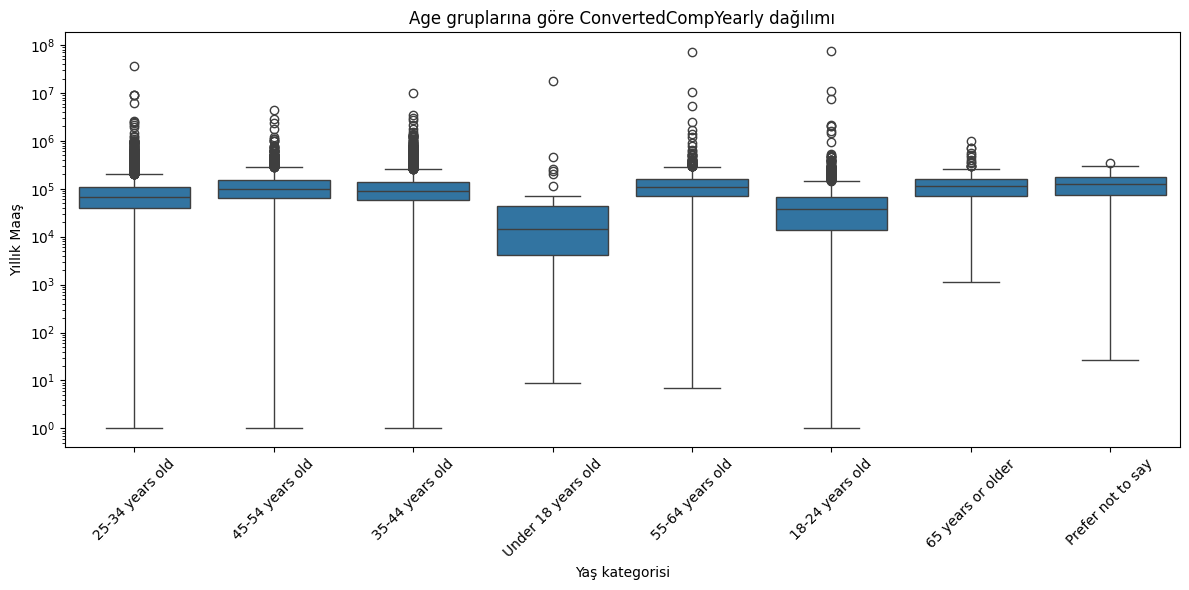

In [14]:
plt.figure(figsize=(12, 6))

df6["Age"] = df6["Age"].astype(str)

sns.boxplot(
    data=df6,
    x="Age",
    y="ConvertedCompYearly"
)

plt.xticks(rotation=45)
plt.title("Age gruplarına göre ConvertedCompYearly dağılımı")
plt.ylabel("Yıllık Maaş")
plt.xlabel("Yaş kategorisi")
plt.yscale("log")

plt.tight_layout()
plt.show()

When we examine the relationship between age and annual salary, we can see that the median values are very close to each other for all age groups except the 0–24 range.
Additionally, the salary range is noticeably wider within the 0–24 age group compared to the others.


This cell visualizes how the average annual salary changes with the number of programming languages known, using a line chart with a log‑scaled y‑axis.

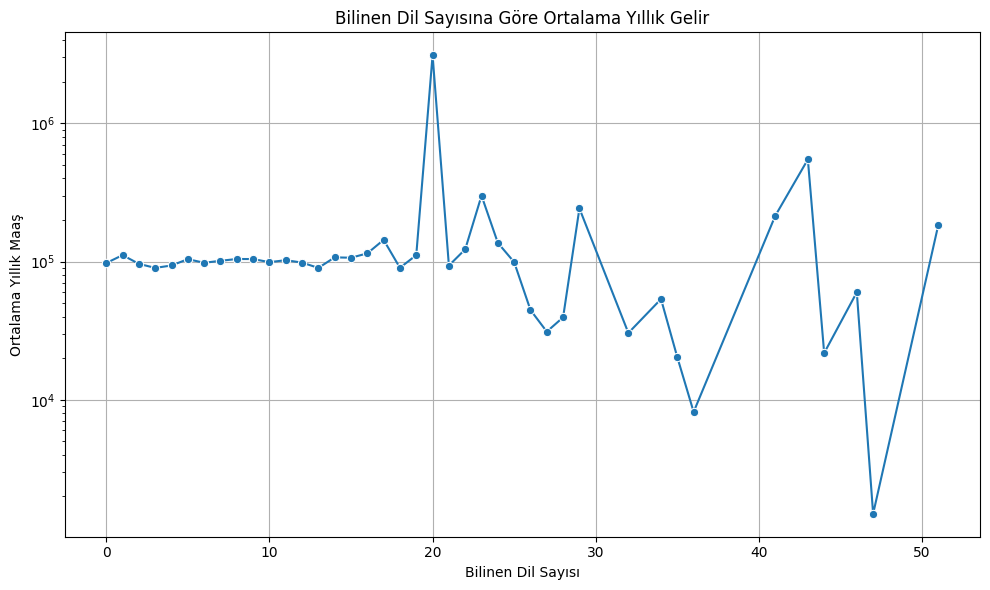

In [15]:
plt.figure(figsize=(10, 6))

mean_df = (
    df6.groupby("LanguageHaveWorkedWith_count")["ConvertedCompYearly"]
       .mean()
       .reset_index()
)

sns.lineplot(
    data=mean_df,
    x="LanguageHaveWorkedWith_count",
    y="ConvertedCompYearly",
    marker="o"
)

plt.title("Bilinen Dil Sayısına Göre Ortalama Yıllık Gelir")
plt.xlabel("Bilinen Dil Sayısı")
plt.ylabel("Ortalama Yıllık Maaş")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

I observe that there is no dramatic salary increase between knowing 1 language and knowing 10 languages.
There appears to be a possible outlier at around 20 languages.
For 25+ languages, the values become extremely volatile.
Based on this, it is clear that knowing more programming languages does not automatically translate into a higher salary.

This cell visualizes the average annual compensation across different ICorPM role types using a bar chart with a log‑scaled salary axis.

C:\Users\yusa.calik_ca\AppData\Local\Temp\3\ipykernel_5576\171967061.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
C:\Users\yusa.calik_ca\AppData\Local\Temp\3\ipykernel_5576\171967061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


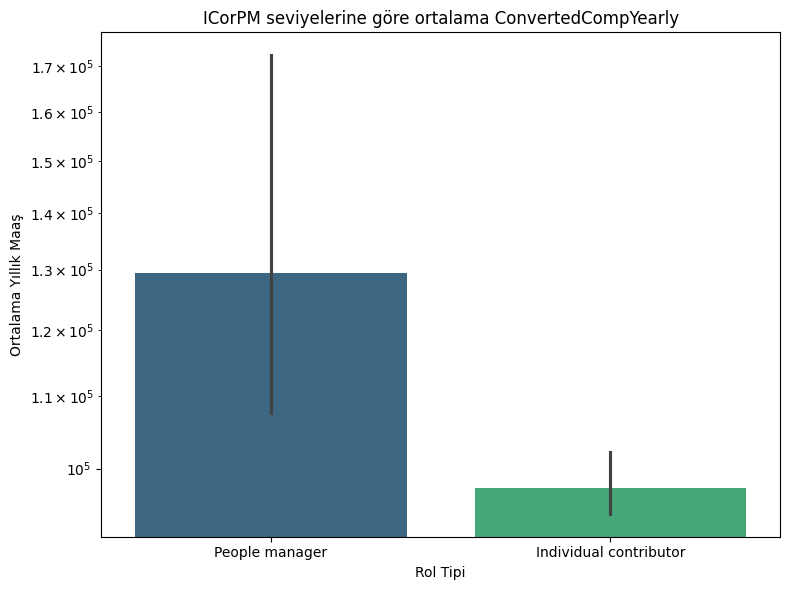

In [16]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df6,
    x="ICorPM",
    y="ConvertedCompYearly",
    estimator="mean",
    ci=95,
    palette="viridis"
)

plt.title("ICorPM seviyelerine göre ortalama ConvertedCompYearly")
plt.ylabel("Ortalama Yıllık Maaş")
plt.xlabel("Rol Tipi")
plt.yscale("log")
plt.tight_layout()
plt.show()

I observe that people in managerial roles tend to have higher average salaries.
For individuals on the “Individual Contributor” side, the error bar is narrower, indicating that salary distribution is more stable and shows less variability.

This cell identifies all object-type columns and applies one‑hot encoding to them.

In [18]:
object_cols = df6.select_dtypes(include="object").columns
df_encoded = pd.get_dummies(df6, columns=object_cols, drop_first=True)


This cell detects duplicate column names, prints them, and removes duplicates to create a clean DataFrame.

In [19]:
df7 = df_encoded.copy()

duplicates = df7.columns[df7.columns.duplicated()].tolist()
print("Duplicate kolonlar:", duplicates)

df8 = df7.loc[:, ~df7.columns.duplicated()].copy()

Duplicate kolonlar: []


This cell converts all boolean columns into integer format (0/1).

In [20]:

bool_cols = df8.select_dtypes(include=["bool"]).columns
df8[bool_cols] = df8[bool_cols].astype(int)


This cell prepares the full machine learning pipeline: outlier removal, log‑target transformation, multicollinearity filtering, data splitting, preprocessing, hyperparameter tuning with GridSearchCV, and evaluation of the XGBoost regression model.

In [21]:
# =====================================================
# 1) IMPORTS
# =====================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor


# =====================================================
# 2) OUTLIER CLEANING
# =====================================================
def remove_outliers(df, col, q=0.99):
    # Keep values below the chosen upper quantile to remove extreme outliers
    upper = df[col].quantile(q)
    df = df[df[col] <= upper]
    return df

df9 = remove_outliers(df8.copy(), "ConvertedCompYearly", q=0.99)


# =====================================================
# 3) LOG TARGET TRANSFORMATION
# =====================================================
# Use log1p transform to stabilize variance and reduce right skewness
df9["target_log"] = np.log1p(df9["ConvertedCompYearly"])

TARGET = "target_log"

y = df9[TARGET]
X = df9.drop(columns=[TARGET, "ConvertedCompYearly"])


# =====================================================
# 4) MULTICOLLINEARITY FILTER
# =====================================================
def high_corr(df, th=0.90):
    # Detect highly correlated numerical features using upper-triangle matrix
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
    return [c for c in upper.columns if any(upper[c] > th)]

num_cols_all = X.select_dtypes(include=["int64","float64"]).columns.tolist()
drop_cols = high_corr(X[num_cols_all], 0.90)
print("Drop:", drop_cols)

# Remove highly correlated columns
X = X.drop(columns=drop_cols)


# =====================================================
# 5) TRAIN / VALID / TEST SPLIT
# =====================================================
# 80% temp + 20% test / then 75% train + 25% validation from temp
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Train:", X_train.shape)
print("Valid:", X_val.shape)
print("Test :", X_test.shape)


# =====================================================
# 6) COLUMN TYPES
# =====================================================
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()


# =====================================================
# 7) PREPROCESSOR (Ordinal Encoding + Scaling)
# =====================================================
# - Categorical: OrdinalEncoder
# - Numerical: StandardScaler
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


# =====================================================
# 8) MODEL (XGBoost optimized)
# =====================================================
pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42
    ))
])

# Hyperparameter search grid
param_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.03, 0.06],
    "model__subsample": [0.7, 1.0],
    "model__colsample_bytree": [0.7, 1.0]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)


# =====================================================
# 9) VALIDATION SCORE
# =====================================================
val_pred_log = grid.predict(X_val)
val_pred = np.expm1(val_pred_log)
y_val_real = np.expm1(y_val)

print("\n===== VALIDATION RESULTS =====")
print("R2:", r2_score(y_val_real, val_pred))
print("MAPE:", mean_absolute_percentage_error(y_val_real, val_pred)*100, "%")


# =====================================================
# 10) TEST SCORE
# =====================================================
test_pred_log = grid.predict(X_test)
test_pred = np.expm1(test_pred_log)
y_test_real = np.expm1(y_test)

print("\n===== TEST RESULTS =====")
print("R2:", r2_score(y_test_real, test_pred))
print("MAPE:", mean_absolute_percentage_error(y_test_real, test_pred)*100, "%")

Drop: []
Train: (28446, 195)
Valid: (9483, 195)
Test : (9483, 195)
Fitting 3 folds for each of 32 candidates, totalling 96 fits

===== VALIDATION RESULTS =====
R2: 0.19404411846295833
MAPE: 3749.2793981569725 %

===== TEST RESULTS =====
R2: 0.18723764185926262
MAPE: 1433.1274371533518 %


(Key Issues Identified)

Global salary differences not normalized → Country-level income inequality overwhelms the model.
Missing high-impact salary predictors (role seniority, company size, negotiation, industry salary structure).
Weak relationship between engineered features and income (many binary features add noise).
Highly skewed target distribution, even after log transform.
MAPE unsuitable for salary data, leading to inflated error percentages.


(Why the Model Performed Poorly)

Salary is heavily influenced by external economic factors not present in the dataset.
Dataset includes extreme variability across countries, causing inconsistent patterns.
Some engineered features (e.g., raw counts) are not strongly correlated with salary.
Categorical explosion after encoding increases noise and reduces model generalizability.


(How to Improve the Model)

Normalize salaries using PPP (Purchasing Power Parity) to remove country bias.
Encode country directly, not continent (continent loses important salary signals).
Replace MAPE with MAE or RMSLE, which are more stable for income prediction.
Use CatBoost, which handles categorical features naturally and performs better on this dataset.
Add interaction features (Age × YearsCode, WorkExp × DevType, etc.) to capture non-linear patterns.


(Overall Conclusion)
The current model struggles because salary prediction with this dataset is inherently difficult:
Large global disparities, missing critical features, and noisy categorical variables limit the achievable performance.
With proper normalization, better encodings, and improved feature engineering, performance can be significantly increased.